In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from restaurant_risk.dataset.load import load_modeling_dataset
from restaurant_risk.dataset.splits import create_primary_temporal_splits
from restaurant_risk.modeling.baselines import add_smoothed_historical_risk
from restaurant_risk.evaluation.metrics import evaluate_ranking_policy, random_expected_metrics
from restaurant_risk.modeling.features import (
    get_feature_matrix,
    get_target_vector,
    validate_model_feature_schema,
)

In [2]:
project_root = Path.cwd().resolve().parent
database_path = project_root / "data" / "restaurant_risk.duckdb"

TARGET_COLUMN = "target_high_severity"
CAPACITIES = [50, 100, 250, 500]
SELECTED_ALPHA = 5.0

df = load_modeling_dataset(database_path)
train_df, validation_df, test_df = create_primary_temporal_splits(df)

print(f"Training rows: {len(train_df):,}")
print(f"Validation rows: {len(validation_df):,}")
print(f"Test rows: {len(test_df):,}")
print("Training target rate:",f"{train_df[TARGET_COLUMN].mean():.2%}")
print("Validation target rate:",f"{validation_df[TARGET_COLUMN].mean():.2%}")

Training rows: 12,865
Validation rows: 16,057
Test rows: 6,396
Training target rate: 27.66%
Validation target rate: 28.22%


## 1. Feature Specification

In [3]:
numeric_features = [
    "prior_cycle_inspection_count",
    "prior_cycle_initial_count",
    "prior_cycle_reinspection_count",

    "prior_high_severity_inspection_count",
    "prior_high_severity_inspection_rate",
    "high_severity_cycle_inspections_last_365d",

    "prior_critical_violation_count",
    "prior_total_violations",
    "prior_critical_violation_rows",
    "violations_last_365d",
    "critical_violations_last_365d",

    "max_historical_score",
    "average_historical_score",
    "average_score_last_365d",

    "days_since_last_critical_inspection",
    "days_since_last_high_severity_inspection",
]

categorical_features = [
    "borough",
    "cuisine_description",
    "history_depth_bucket",
]

model_features = numeric_features + categorical_features

excluded_or_audit_columns = [
    "camis",
    "cutoff_inspection_id",
    "cutoff_date",
    "feature_source_max_date",
    "violation_feature_source_max_date",
    "last_cycle_inspection_date",
    "last_critical_inspection_date",
    "last_high_severity_inspection_date",
    "days_since_last_cycle_inspection",
    "prior_critical_inspection_rate",
    "zipcode",
    "nta",
    "community_board",
    "has_no_cycle_initial_history",
    "cutoff_inspection_type",
    "cutoff_is_cycle_initial",
    "cutoff_is_cycle_reinspection",
    "target_inspection_id",
    "target_inspection_date",
    "target_inspection_type",
    "days_to_target",
    "target_total_violations",
    "target_critical_violation_count",
    "target_any_critical",
    "target_two_or_more_critical",
    "target_three_or_more_critical",
    "target_four_or_more_critical",
    "target_high_severity",
    "target_label",
]

missing_features = [ column for column in model_features if column not in train_df.columns]

print("Missing model features:", missing_features)
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Total model features before encoding:", len(model_features))

Missing model features: []
Number of numeric features: 16
Number of categorical features: 3
Total model features before encoding: 19


In [4]:
X_train = train_df[model_features].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_validation = validation_df[model_features].copy()
y_validation = validation_df[TARGET_COLUMN].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

X_train shape: (12865, 19)
y_train shape: (12865,)
X_validation shape: (16057, 19)
y_validation shape: (16057,)


## 2. Leakage-Safe Preprocessing Pipeline

In [5]:
numeric_preprocessor = Pipeline(steps=[("imputer",SimpleImputer(strategy="median",add_indicator=True)),("scaler",StandardScaler())])
categorical_preprocessor = Pipeline(steps=[("imputer",SimpleImputer(strategy="constant",fill_value="Missing")),("onehot",OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(transformers=[("numeric",numeric_preprocessor,numeric_features),("categorical",categorical_preprocessor,categorical_features)],remainder="drop")

In [6]:
logistic_model = LogisticRegression(
    C=1.0,
    max_iter=1_000,
    solver="lbfgs",
    random_state=42,
)

logistic_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("classifier", logistic_model)])

In [7]:
logistic_pipeline.fit(X_train,y_train)

print("Logistic regression training completed.")

Logistic regression training completed.


In [8]:
validation_logistic_scores = logistic_pipeline.predict_proba(X_validation)[:, 1]
validation_logistic_scores[:10]

array([0.06645898, 0.38732337, 0.2689392 , 0.1357661 , 0.349776  ,
       0.32026228, 0.41099655, 0.10825285, 0.40526125, 0.24238497])

In [9]:
validation_logistic_scored = validation_df.copy()
validation_logistic_scored["logistic_risk_score"] = validation_logistic_scores
validation_logistic_scored[
    [
        "camis",
        "cutoff_date",
        "prior_high_severity_inspection_rate",
        "logistic_risk_score",
        TARGET_COLUMN,
    ]
].head(10)

,camis,cutoff_date,prior_high_severity_inspection_rate,logistic_risk_score,target_high_severity
0,50065575,2024-05-29,0.000000,0.066459,0
1,50120864,2024-05-08,0.500000,0.387323,0
2,41431607,2024-05-15,0.000000,0.268939,0
3,50043074,2024-12-06,0.000000,0.135766,0
6,50122409,2024-11-25,1.000000,0.349776,1
12,50125902,2024-11-21,1.000000,0.320262,0
13,40378212,2024-01-23,1.000000,0.410997,1
14,50107955,2024-10-15,0.000000,0.108253,0
16,41629073,2024-03-14,0.666667,0.405261,0
17,50014920,2024-05-29,0.333333,0.242385,0


## 3. Validation Evaluation: Historical Baseline vs Logistic Regression

In [10]:
SELECTED_ALPHA = 5.0

validation_baseline_scored = add_smoothed_historical_risk(
    train_df=train_df,
    data_to_score=validation_df,
    alpha=SELECTED_ALPHA,
    score_column="historical_risk_score",
)

validation_baseline_scored[
    [
        "camis",
        "cutoff_date",
        "prior_high_severity_inspection_count",
        "prior_cycle_inspection_count",
        "historical_risk_score",
        TARGET_COLUMN,
    ]
].head(10)

,camis,cutoff_date,prior_high_severity_inspection_count,prior_cycle_inspection_count,historical_risk_score,target_high_severity
0,50065575,2024-05-29,0,2,0.197601,0
1,50120864,2024-05-08,1,2,0.340459,0
2,41431607,2024-05-15,0,2,0.197601,0
3,50043074,2024-12-06,0,1,0.230535,0
6,50122409,2024-11-25,1,1,0.397202,1
12,50125902,2024-11-21,1,1,0.397202,0
13,40378212,2024-01-23,1,1,0.397202,1
14,50107955,2024-10-15,0,2,0.197601,0
16,41629073,2024-03-14,2,3,0.422901,0
17,50014920,2024-05-29,1,3,0.297901,0


In [11]:
validation_comparison_df = validation_baseline_scored.copy()

validation_comparison_df["logistic_risk_score"] = (
    validation_logistic_scores
)

validation_comparison_df[
    [
        "camis",
        "historical_risk_score",
        "logistic_risk_score",
        TARGET_COLUMN,
    ]
].head(10)

,camis,historical_risk_score,logistic_risk_score,target_high_severity
0,50065575,0.197601,0.066459,0
1,50120864,0.340459,0.387323,0
2,41431607,0.197601,0.268939,0
3,50043074,0.230535,0.135766,0
6,50122409,0.397202,0.349776,1
12,50125902,0.397202,0.320262,0
13,40378212,0.397202,0.410997,1
14,50107955,0.197601,0.108253,0
16,41629073,0.422901,0.405261,0
17,50014920,0.297901,0.242385,0


In [12]:
validation_global_metrics = pd.DataFrame(
    [
        {
            "model": "smoothed_historical_risk",

            "average_precision": average_precision_score(
                y_validation,
                validation_comparison_df[
                    "historical_risk_score"
                ],
            ),

            "roc_auc": roc_auc_score(
                y_validation,
                validation_comparison_df[
                    "historical_risk_score"
                ],
            ),

            "brier_score": brier_score_loss(
                y_validation,
                validation_comparison_df[
                    "historical_risk_score"
                ],
            ),
        },
        {
            "model": "logistic_regression",

            "average_precision": average_precision_score(
                y_validation,
                validation_comparison_df[
                    "logistic_risk_score"
                ],
            ),

            "roc_auc": roc_auc_score(
                y_validation,
                validation_comparison_df[
                    "logistic_risk_score"
                ],
            ),

            "brier_score": brier_score_loss(
                y_validation,
                validation_comparison_df[
                    "logistic_risk_score"
                ],
            ),
        },
    ]
)

validation_global_metrics

,model,average_precision,roc_auc,brier_score
0,smoothed_historical_risk,0.390698,0.642528,0.192108
1,logistic_regression,0.456674,0.696448,0.184279


In [13]:
validation_policy_rows = []

score_policies = [
    (
        "smoothed_historical_risk",
        "historical_risk_score",
    ),
    (
        "logistic_regression",
        "logistic_risk_score",
    ),
]

for capacity in CAPACITIES:
    random_metrics = random_expected_metrics(
        data=validation_comparison_df,
        capacity=capacity,
    )

    validation_policy_rows.append(
        {
            "policy": "random_expected",
            "capacity": capacity,
            "outcomes_found": (
                random_metrics[
                    "expected_high_severity_outcomes"
                ]
            ),
            "precision_at_k": (
                random_metrics[
                    "expected_precision_at_k"
                ]
            ),
            "recall_at_k": None,
            "lift_vs_random": 1.0,
            "incremental_outcomes_vs_random": 0.0,
        }
    )

    for policy_name, score_column in score_policies:
        policy_metrics = evaluate_ranking_policy(
            data=validation_comparison_df,
            score_column=score_column,
            capacity=capacity,
            policy_name=policy_name,
        )

        validation_policy_rows.append(
            {
                "policy": policy_name,
                "capacity": capacity,
                "outcomes_found": (
                    policy_metrics[
                        "high_severity_outcomes_found"
                    ]
                ),
                "precision_at_k": (
                    policy_metrics[
                        "precision_at_k"
                    ]
                ),
                "recall_at_k": (
                    policy_metrics[
                        "recall_at_k"
                    ]
                ),
                "lift_vs_random": (
                    policy_metrics[
                        "lift_vs_random"
                    ]
                ),
                "incremental_outcomes_vs_random": (
                    policy_metrics[
                        "high_severity_outcomes_found"
                    ]
                    - random_metrics[
                        "expected_high_severity_outcomes"
                    ]
                ),
            }
        )

validation_policy_results = pd.DataFrame(
    validation_policy_rows
)

validation_policy_results.sort_values(
    ["capacity", "policy"]
)

,policy,capacity,outcomes_found,precision_at_k,recall_at_k,lift_vs_random,incremental_outcomes_vs_random
2,logistic_regression,50,33.000000,0.660000,0.007283,2.338914,18.890889
0,random_expected,50,14.109111,0.282182,NaN,1.000000,0.000000
1,smoothed_historical_risk,50,23.000000,0.460000,0.005076,1.630152,8.890889
5,logistic_regression,100,64.000000,0.640000,0.014125,2.268038,35.781777
3,random_expected,100,28.218223,0.282182,NaN,1.000000,0.000000
4,smoothed_historical_risk,100,53.000000,0.530000,0.011697,1.878219,24.781777
8,logistic_regression,250,152.000000,0.608000,0.033547,2.154636,81.454444
6,random_expected,250,70.545556,0.282182,NaN,1.000000,0.000000
7,smoothed_historical_risk,250,124.000000,0.496000,0.027367,1.757729,53.454444
11,logistic_regression,500,301.000000,0.602000,0.066431,2.133373,159.908887


## 4. Logistic Regression Regularization Selection

In [14]:
C_CANDIDATES = [0.1, 1.0, 2.0, 5.0, 8.0, 10.0]

logistic_validation_scores_by_c = {}

for c_value in C_CANDIDATES:
    candidate_model = LogisticRegression(
        C=c_value,
        max_iter=1_000,
        solver="lbfgs",
        random_state=42,
    )

    candidate_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", candidate_model),
        ]
    )

    candidate_pipeline.fit(
        X_train,
        y_train,
    )

    candidate_scores = candidate_pipeline.predict_proba(
        X_validation
    )[:, 1]

    logistic_validation_scores_by_c[c_value] = candidate_scores

    print(
        f"C={c_value:<4} | "
        f"min={candidate_scores.min():.4f} | "
        f"mean={candidate_scores.mean():.4f} | "
        f"max={candidate_scores.max():.4f}"
    )

C=0.1  | min=0.0157 | mean=0.2609 | max=0.9855
C=1.0  | min=0.0072 | mean=0.2591 | max=0.9841
C=2.0  | min=0.0036 | mean=0.2591 | max=0.9845
C=5.0  | min=0.0018 | mean=0.2589 | max=0.9844
C=8.0  | min=0.0012 | mean=0.2588 | max=0.9847
C=10.0 | min=0.0004 | mean=0.2587 | max=0.9843


In [15]:
logistic_c_global_rows = []

for c_value, scores in logistic_validation_scores_by_c.items():
    logistic_c_global_rows.append(
        {
            "C": c_value,
            "average_precision": average_precision_score(
                y_validation,
                scores,
            ),
            "roc_auc": roc_auc_score(
                y_validation,
                scores,
            ),
            "brier_score": brier_score_loss(
                y_validation,
                scores,
            ),
        }
    )

logistic_c_global_metrics = (
    pd.DataFrame(logistic_c_global_rows)
    .sort_values("C")
)

logistic_c_global_metrics

,C,average_precision,roc_auc,brier_score
0,0.1,0.456705,0.698109,0.183887
1,1.0,0.456674,0.696448,0.184279
2,2.0,0.455883,0.695921,0.184444
3,5.0,0.455480,0.695434,0.184589
4,8.0,0.455421,0.695329,0.184648
5,10.0,0.455039,0.694845,0.184738


In [16]:
logistic_c_policy_rows = []

for c_value, scores in logistic_validation_scores_by_c.items():
    scored_validation = validation_df.copy()
    scored_validation["logistic_risk_score"] = scores

    for capacity in CAPACITIES:
        policy_metrics = evaluate_ranking_policy(
            data=scored_validation,
            score_column="logistic_risk_score",
            capacity=capacity,
            policy_name=f"logistic_regression_C_{c_value}",
        )

        baseline_metrics = evaluate_ranking_policy(
            data=validation_comparison_df,
            score_column="historical_risk_score",
            capacity=capacity,
            policy_name="smoothed_historical_risk",
        )

        logistic_c_policy_rows.append(
            {
                "C": c_value,
                "capacity": capacity,

                "logistic_outcomes_found": policy_metrics[
                    "high_severity_outcomes_found"
                ],
                "logistic_precision_at_k": policy_metrics[
                    "precision_at_k"
                ],
                "logistic_lift_vs_random": policy_metrics[
                    "lift_vs_random"
                ],

                "incremental_outcomes_vs_baseline": (
                    policy_metrics[
                        "high_severity_outcomes_found"
                    ]
                    - baseline_metrics[
                        "high_severity_outcomes_found"
                    ]
                ),
            }
        )

logistic_c_policy_results = (
    pd.DataFrame(logistic_c_policy_rows)
    .sort_values(["capacity", "C"])
)

logistic_c_policy_results

,C,capacity,logistic_outcomes_found,logistic_precision_at_k,logistic_lift_vs_random,incremental_outcomes_vs_baseline
0,0.1,50,35,0.700,2.480667,12
4,1.0,50,33,0.660,2.338914,10
8,2.0,50,34,0.680,2.409790,11
12,5.0,50,34,0.680,2.409790,11
16,8.0,50,33,0.660,2.338914,10
20,10.0,50,33,0.660,2.338914,10
1,0.1,100,62,0.620,2.197162,9
5,1.0,100,64,0.640,2.268038,11
9,2.0,100,64,0.640,2.268038,11
13,5.0,100,63,0.630,2.232600,10


## 5. Logistic Regression Probability Calibration

In [17]:
FINAL_C = 1.0

final_logistic_model = LogisticRegression(
    C=FINAL_C,
    max_iter=1_000,
    solver="lbfgs",
    random_state=42,
)

final_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", final_logistic_model),
    ]
)

final_logistic_pipeline.fit(X_train, y_train)

validation_final_scores = final_logistic_pipeline.predict_proba(
    X_validation
)[:, 1]

validation_final_df = validation_df.copy()
validation_final_df["logistic_risk_score"] = validation_final_scores

print(
    "Final logistic model (C=1.0) fitted on training data."
)
print(
    "Validation score range:",
    f"{validation_final_scores.min():.4f} – {validation_final_scores.max():.4f}",
)
print(
    "Validation mean score:",
    f"{validation_final_scores.mean():.4f}",
)

Final logistic model (C=1.0) fitted on training data.
Validation score range: 0.0072 – 0.9841
Validation mean score: 0.2591


In [18]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_validation,
    validation_final_scores,
    n_bins=10,
)

calibration_df = pd.DataFrame(
    {
        "predicted_risk_bin_mean": prob_pred,
        "observed_high_severity_rate": prob_true,
    }
)

calibration_df

,predicted_risk_bin_mean,observed_high_severity_rate
0,0.075685,0.094399
1,0.152355,0.179039
2,0.248382,0.288962
3,0.345562,0.370755
4,0.444131,0.473267
5,0.545051,0.521795
6,0.640970,0.601881
7,0.741908,0.592593
8,0.842371,0.658537
9,0.923707,0.636364


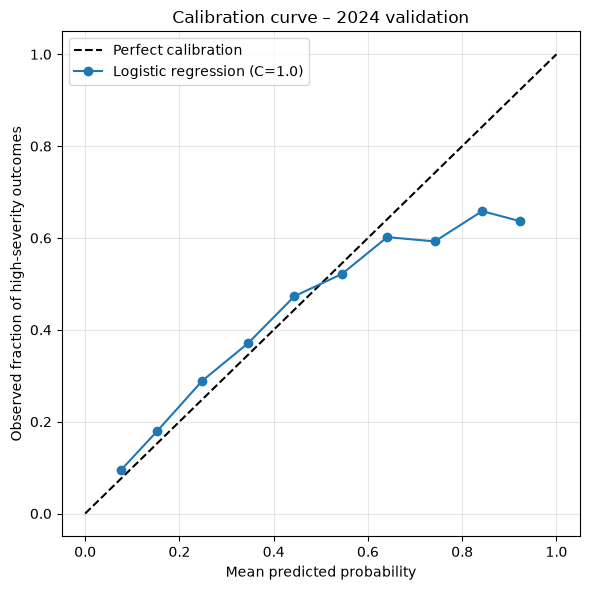

In [19]:
plt.figure(figsize=(6, 6))

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Perfect calibration",
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic regression (C=1.0)",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction of high-severity outcomes")
plt.title("Calibration curve – 2024 validation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Final Test Evaluation (2025)

In [20]:
print("Test rows:", len(test_df))
print(
    "Test target prevalence:",
    f"{test_df[TARGET_COLUMN].mean():.2%}",
)

test_df[[TARGET_COLUMN]].describe()

Test rows: 6396
Test target prevalence: 37.20%


,target_high_severity
count,6396.000000
mean,0.371951
std,0.483363
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [21]:
X_test = get_feature_matrix(test_df)
y_test = get_target_vector(test_df)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (6396, 21)
y_test shape: (6396,)


In [22]:
test_logistic_scores = final_logistic_pipeline.predict_proba(X_test)[:, 1]

test_scored = test_df.copy()
test_scored["logistic_risk_score"] = test_logistic_scores

print(
    "Test logistic score range:",
    f"{test_logistic_scores.min():.4f} – {test_logistic_scores.max():.4f}",
)
print(
    "Test logistic mean score:",
    f"{test_logistic_scores.mean():.4f}",
)

Test logistic score range: 0.0065 – 0.9866
Test logistic mean score: 0.2792


In [23]:
SELECTED_ALPHA = 5.0

test_baseline_scored = add_smoothed_historical_risk(
    train_df=train_df,
    data_to_score=test_df,
    alpha=SELECTED_ALPHA,
    score_column="historical_risk_score",
)

test_baseline_scored[
    [
        "camis",
        "cutoff_date",
        "prior_high_severity_inspection_count",
        "prior_cycle_inspection_count",
        "historical_risk_score",
        TARGET_COLUMN,
    ]
].head(10)

,camis,cutoff_date,prior_high_severity_inspection_count,prior_cycle_inspection_count,historical_risk_score,target_high_severity
4,41047349,2025-01-14,0,2,0.197601,0
5,50119840,2025-07-15,1,4,0.264801,1
7,50117697,2025-04-03,3,4,0.487023,0
9,40530630,2025-04-09,0,5,0.138321,0
25,50092484,2025-05-12,2,3,0.422901,1
45,40818115,2025-05-13,0,2,0.197601,0
47,50156239,2025-05-16,1,1,0.397202,1
56,50112504,2025-08-25,3,4,0.487023,1
63,50110783,2025-05-14,1,3,0.297901,0
65,50081134,2025-02-20,0,2,0.197601,0


In [24]:
test_comparison_df = test_baseline_scored.copy()
test_comparison_df["logistic_risk_score"] = test_logistic_scores

test_comparison_df[
    [
        "camis",
        "historical_risk_score",
        "logistic_risk_score",
        TARGET_COLUMN,
    ]
].head(10)

,camis,historical_risk_score,logistic_risk_score,target_high_severity
4,41047349,0.197601,0.155675,0
5,50119840,0.264801,0.275364,1
7,50117697,0.487023,0.967068,0
9,40530630,0.138321,0.142751,0
25,50092484,0.422901,0.163624,1
45,40818115,0.197601,0.073785,0
47,50156239,0.397202,0.393428,1
56,50112504,0.487023,0.702156,1
63,50110783,0.297901,0.103290,0
65,50081134,0.197601,0.185293,0


In [25]:
test_global_metrics = pd.DataFrame(
    [
        {
            "model": "smoothed_historical_risk",
            "average_precision": average_precision_score(
                y_test,
                test_comparison_df["historical_risk_score"],
            ),
            "roc_auc": roc_auc_score(
                y_test,
                test_comparison_df["historical_risk_score"],
            ),
            "brier_score": brier_score_loss(
                y_test,
                test_comparison_df["historical_risk_score"],
            ),
        },
        {
            "model": "logistic_regression",
            "average_precision": average_precision_score(
                y_test,
                test_comparison_df["logistic_risk_score"],
            ),
            "roc_auc": roc_auc_score(
                y_test,
                test_comparison_df["logistic_risk_score"],
            ),
            "brier_score": brier_score_loss(
                y_test,
                test_comparison_df["logistic_risk_score"],
            ),
        },
    ]
)

test_global_metrics

,model,average_precision,roc_auc,brier_score
0,smoothed_historical_risk,0.522366,0.663238,0.218262
1,logistic_regression,0.564124,0.692371,0.219819


In [26]:
test_policy_rows = []

score_policies = [
    (
        "smoothed_historical_risk",
        "historical_risk_score",
    ),
    (
        "logistic_regression",
        "logistic_risk_score",
    ),
]

for capacity in CAPACITIES:
    random_metrics = random_expected_metrics(
        data=test_comparison_df,
        capacity=capacity,
    )

    test_policy_rows.append(
        {
            "policy": "random_expected",
            "capacity": capacity,
            "outcomes_found": (
                random_metrics[
                    "expected_high_severity_outcomes"
                ]
            ),
            "precision_at_k": (
                random_metrics[
                    "expected_precision_at_k"
                ]
            ),
            "recall_at_k": None,
            "lift_vs_random": 1.0,
            "incremental_outcomes_vs_random": 0.0,
        }
    )

    for policy_name, score_column in score_policies:
        policy_metrics = evaluate_ranking_policy(
            data=test_comparison_df,
            score_column=score_column,
            capacity=capacity,
            policy_name=policy_name,
        )

        test_policy_rows.append(
            {
                "policy": policy_name,
                "capacity": capacity,
                "outcomes_found": (
                    policy_metrics[
                        "high_severity_outcomes_found"
                    ]
                ),
                "precision_at_k": (
                    policy_metrics[
                        "precision_at_k"
                    ]
                ),
                "recall_at_k": (
                    policy_metrics[
                        "recall_at_k"
                    ]
                ),
                "lift_vs_random": (
                    policy_metrics[
                        "lift_vs_random"
                    ]
                ),
                "incremental_outcomes_vs_random": (
                    policy_metrics[
                        "high_severity_outcomes_found"
                    ]
                    - random_metrics[
                        "expected_high_severity_outcomes"
                    ]
                ),
            }
        )

test_policy_results = pd.DataFrame(test_policy_rows)

test_policy_results.sort_values(["capacity", "policy"])

,policy,capacity,outcomes_found,precision_at_k,recall_at_k,lift_vs_random,incremental_outcomes_vs_random
2,logistic_regression,50,44.000000,0.880000,0.018495,2.365902,25.402439
0,random_expected,50,18.597561,0.371951,NaN,1.000000,0.000000
1,smoothed_historical_risk,50,33.000000,0.660000,0.013871,1.774426,14.402439
5,logistic_regression,100,81.000000,0.810000,0.034048,2.177705,43.804878
3,random_expected,100,37.195122,0.371951,NaN,1.000000,0.000000
4,smoothed_historical_risk,100,72.000000,0.720000,0.030265,1.935738,34.804878
8,logistic_regression,250,188.000000,0.752000,0.079025,2.021770,95.012195
6,random_expected,250,92.987805,0.371951,NaN,1.000000,0.000000
7,smoothed_historical_risk,250,171.000000,0.684000,0.071879,1.838951,78.012195
11,logistic_regression,500,333.000000,0.666000,0.139975,1.790557,147.024390


## 7. Interpretation

On the untouched 2025 test period, the frozen logistic-regression model
(C = 1.0, 19 historical features) outperformed the smoothed historical-risk
baseline (alpha = 5) under fixed inspection capacities.

Key findings:

- Global ranking metrics improved:
  - Average precision: 0.522 → 0.564
  - ROC-AUC: 0.663 → 0.692
- Capacity-aware yield increased at all tested budgets:
  - At capacity 100: 72 → 81 high-severity outcomes (+9)
  - At capacity 250: 171 → 188 high-severity outcomes (+17)
  - At capacity 500: 324 → 333 high-severity outcomes (+9)

These results confirm that multivariable logistic regression provides
operationally meaningful improvements over a strong historical-risk baseline
when prioritizing routine cycle-initial inspections for future high-severity
outcomes.

The model is now frozen for production use:

```text
Features: 19 approved historical features
Preprocessing: median imputation + missingness indicators + scaling
               categorical imputation + one-hot encoding
Model: logistic regression with C = 1.0
```

No further tuning or feature changes should be made without a new, temporally
held-out evaluation.

In [27]:
import joblib

project_root = Path.cwd().resolve().parent
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "logistic_regression_C1.joblib"

joblib.dump(final_logistic_pipeline, model_path)

print("Saved final logistic pipeline to:", model_path)
print("File exists:", model_path.exists())

Saved final logistic pipeline to: C:\Users\User\projects\restaurant-inspection-prioritization\models\logistic_regression_C1.joblib
File exists: True


## 8. Calibration

In [29]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

from restaurant_risk.modeling.calibration import SigmoidCalibrator

In [30]:
from restaurant_risk.modeling.calibration import SigmoidCalibrator

sigmoid_calibrator = SigmoidCalibrator()

sigmoid_calibrator.fit(
    model=final_logistic_pipeline,
    calibration_df=validation_df,
)

print("Sigmoid calibrator fitted on 2024 validation data.")

Sigmoid calibrator fitted on 2024 validation data.


In [37]:
test_calibrated_scores = (
    sigmoid_calibrator.predict_positive_probability(
        model=final_logistic_pipeline,
        data_to_score=test_df,
    )
)

In [38]:
from sklearn.metrics import brier_score_loss

test_raw_brier = brier_score_loss(
    y_test,
    test_logistic_scores,
)

test_calibrated_brier = brier_score_loss(
    y_test,
    test_calibrated_scores,
)

print(f"2025 test raw Brier:        {test_raw_brier:.4f}")
print(f"2025 test calibrated Brier: {test_calibrated_brier:.4f}")

2025 test raw Brier:        0.2198
2025 test calibrated Brier: 0.2151


In [40]:
CAPACITIES = [50, 100, 250, 500]

top_n_calibration_comparison = []

for n in CAPACITIES:
    raw_scores = pd.Series(
        test_logistic_scores,
        index=test_df.index,
    )

    calibrated_scores = pd.Series(
        test_calibrated_scores,
        index=test_df.index,
    )

    raw_top_n = raw_scores.nlargest(n).index
    calibrated_top_n = calibrated_scores.nlargest(n).index

    raw_yield = y_test.loc[raw_top_n].sum()
    calibrated_yield = y_test.loc[calibrated_top_n].sum()

    top_n_calibration_comparison.append(
        {
            "capacity": n,
            "raw_logistic_yield": int(raw_yield),
            "calibrated_logistic_yield": int(calibrated_yield),
            "raw_precision": raw_yield / n,
            "calibrated_precision": calibrated_yield / n,
        }
    )

top_n_calibration_comparison = pd.DataFrame(
    top_n_calibration_comparison
)

top_n_calibration_comparison

,capacity,raw_logistic_yield,calibrated_logistic_yield,raw_precision,calibrated_precision
0,50,44,44,0.880,0.880
1,100,81,81,0.810,0.810
2,250,188,188,0.752,0.752
3,500,333,333,0.666,0.666


In [41]:
raw_prob_true, raw_prob_pred = calibration_curve(
    y_test,
    test_logistic_scores,
    n_bins=10,
)

calibrated_prob_true, calibrated_prob_pred = calibration_curve(
    y_test,
    test_calibrated_scores,
    n_bins=10,
)

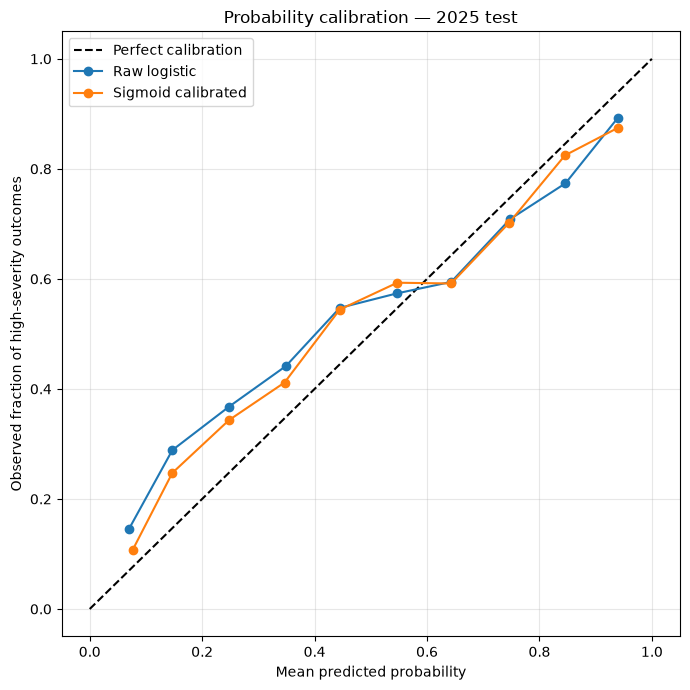

In [42]:
plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Perfect calibration",
)

plt.plot(
    raw_prob_pred,
    raw_prob_true,
    marker="o",
    label="Raw logistic",
)

plt.plot(
    calibrated_prob_pred,
    calibrated_prob_true,
    marker="o",
    label="Sigmoid calibrated",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction of high-severity outcomes")
plt.title("Probability calibration — 2025 test")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
calibrator_path = (
    Path.cwd().parent
    / "models"
    / "logistic_regression_C1_sigmoid_calibrator.joblib"
)

joblib.dump(
    sigmoid_calibrator,
    calibrator_path,
)

print(f"Saved calibrator to: {calibrator_path.resolve()}")

Saved calibrator to: C:\Users\User\projects\restaurant-inspection-prioritization\models\logistic_regression_C1_sigmoid_calibrator.joblib
